<div style="background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://sigmoidal.ai/wp-content/uploads/2024/09/Academia-Sigmoidal-Light.png" alt="Academia Sigmoidal Logo" width="250" height="auto">
    <div style="text-align: right;">
<h1 style="color: #007bff; margin: 0; font-size: 24px;">Pós-Graduação em Visão Computacional</h1>
    </div>
</div>
<hr style="border: none; height: 1px; background-color: #007bff; margin: 20px 0;">
<h3 style="color: #343a40; margin: 0; font-size: 20px;"><strong>VIS101: Fundamentos da Visão Computacional</strong></h3>
<p style="color: #6c757d; margin: 5px 0 0; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
</div>

Na aula anterior a imagem foi tratada como uma matriz e manipulada por fora: recortes, canais e transformações geométricas. Nesta aula o olhar se volta para dentro, para a distribuição das intensidades.

A ferramenta central é o **histograma**, o retrato de quantas vezes cada nível de intensidade aparece. A partir dele vêm as **transformações de intensidade**, que ajustam brilho e contraste e realçam a informação que interessa.

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

print('Setup pronto.')

Setup pronto.


## A imagem em tons de cinza

Para estudar a intensidade, trabalhamos em tons de cinza. Assim cada pixel guarda um único número, a sua intensidade luminosa, sem a complicação dos três canais de cor.

In [3]:
img = cv2.imread('../imgs/perfil.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gray.shape, gray.dtype)

(495, 610) uint8


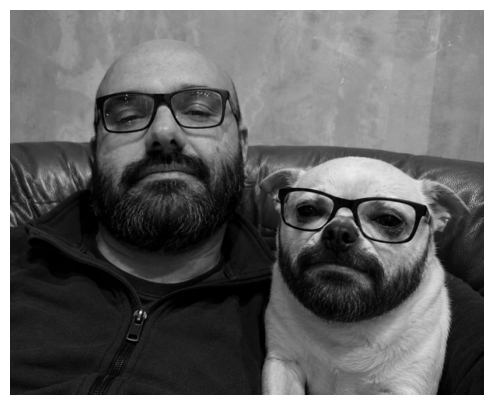

In [4]:
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

Os valores vão de 0 (preto) a 255 (branco), inteiros de 8 bits. É essa faixa que o histograma vai resumir.

## O histograma

O histograma conta, para cada nível de intensidade $k$, quantos pixels têm aquele valor:

$$h(k) = \#\{(x, y) : f(x, y) = k\}$$

É o raio-X da imagem: revela se ela é escura, clara ou de baixo contraste antes mesmo de olharmos para ela.

In [5]:
hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
print('soma do histograma:', int(hist.sum()), ' total de pixels:', gray.size)

soma do histograma: 301950  total de pixels: 301950


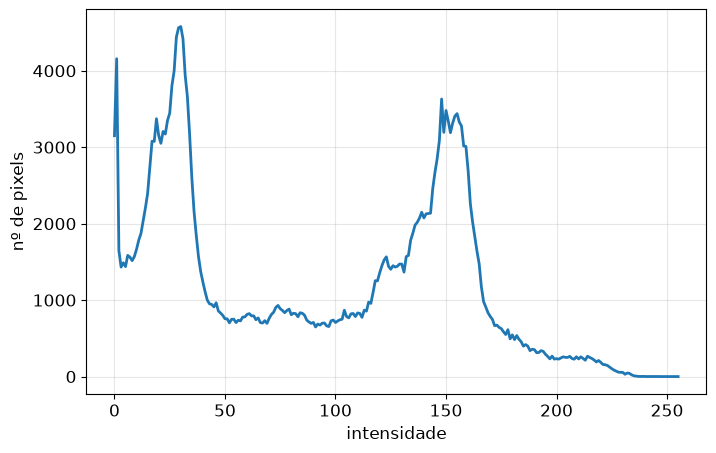

In [6]:
plt.plot(hist)
plt.xlabel('intensidade')
plt.ylabel('nº de pixels')
plt.show()

A soma de todas as barras é igual ao número de pixels. Os picos indicam as intensidades dominantes e os vales, as faixas pouco usadas.

## Lendo o histograma como diagnóstico

O formato do histograma já aponta o problema. Uma imagem escura concentra os valores à esquerda, uma clara à direita, e uma de baixo contraste fica espremida numa faixa estreita. Para ver isso, geramos três versões a partir da própria imagem.

In [7]:
escura = np.clip(gray * 0.4, 0, 255).astype(np.uint8)
clara = np.clip(gray * 0.6 + 120, 0, 255).astype(np.uint8)
baixo = np.clip(gray * 0.35 + 90, 0, 255).astype(np.uint8)
casos = [('normal', gray), ('escura', escura), ('clara', clara), ('baixo contraste', baixo)]

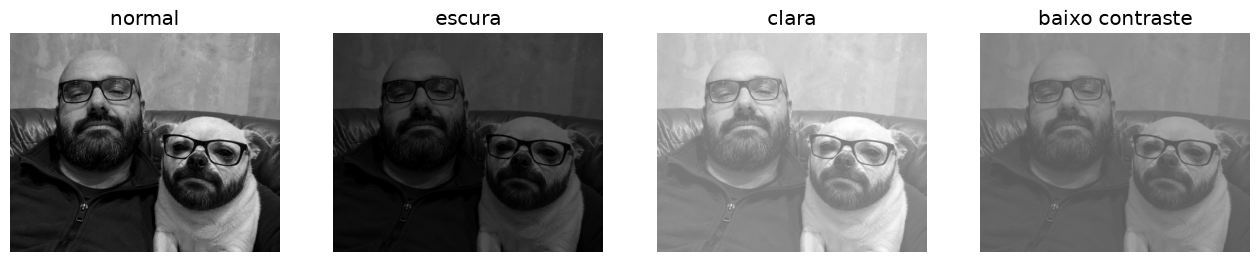

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (nome, im) in zip(axes, casos):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(nome)
    ax.axis('off')
plt.show()

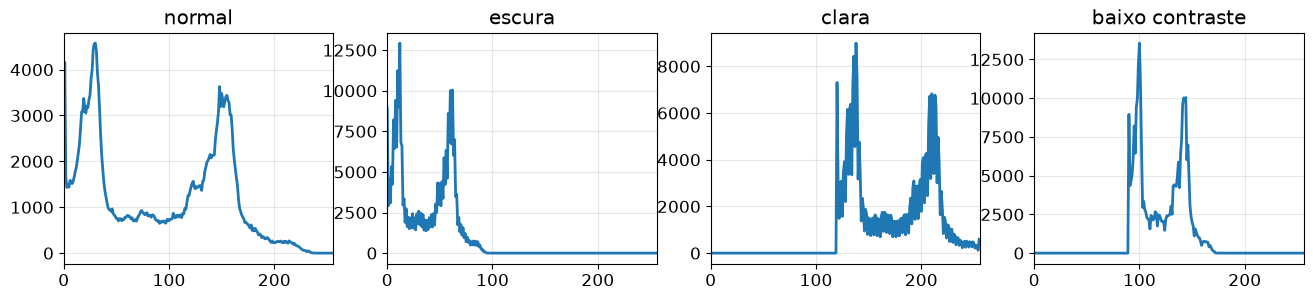

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, (nome, im) in zip(axes, casos):
    ax.plot(cv2.calcHist([im], [0], None, [256], [0, 256]))
    ax.set_xlim([0, 256])
    ax.set_title(nome)
plt.show()

Repare que a informação está no formato, não na imagem em si. O histograma da versão escura empurra tudo para a esquerda; o da versão de baixo contraste vira um pico estreito no meio.

## Transformações de intensidade

Uma transformação de intensidade remapeia cada valor de pixel por uma função:

$$s = T(r)$$

onde $r$ é a intensidade de entrada e $s$ a de saída. É uma operação pontual: o novo valor de um pixel depende apenas do valor antigo dele, não dos vizinhos.

### Brilho

Somar uma constante desloca todas as intensidades para cima, clareando a imagem: $s = r + b$. O `clip` evita que os valores ultrapassem 255.

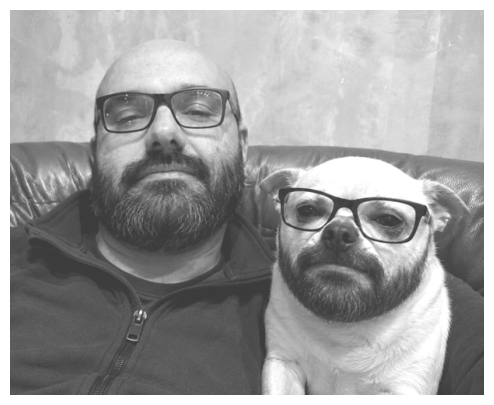

In [10]:
brilho = np.clip(gray.astype(int) + 60, 0, 255).astype(np.uint8)
plt.imshow(brilho, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### Contraste

Multiplicar por um fator maior que 1 afasta as intensidades umas das outras, esticando o histograma: $s = \alpha\, r$.

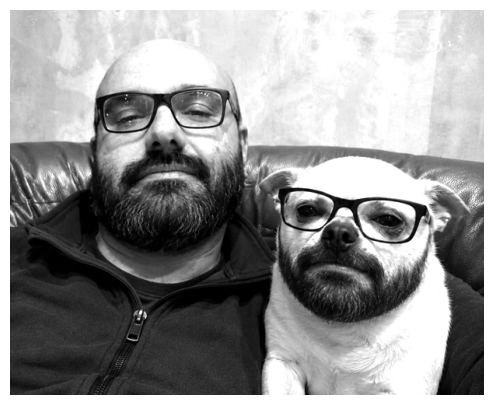

In [11]:
contraste = np.clip(1.6 * gray, 0, 255).astype(np.uint8)
plt.imshow(contraste, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### Negativo

Inverter a intensidade produz o negativo: $s = 255 - r$. É útil para realçar detalhes em regiões escuras, como em radiografias.

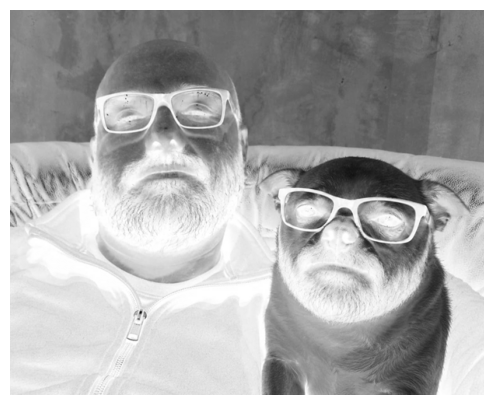

In [12]:
negativo = 255 - gray
plt.imshow(negativo, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### Correção gama

A correção gama é não linear: $s = c\,(r/255)^{\gamma} \cdot 255$. Com $\gamma < 1$ as sombras clareiam; com $\gamma > 1$ elas escurecem. É a curva que descreve como telas e câmeras codificam a luminância.

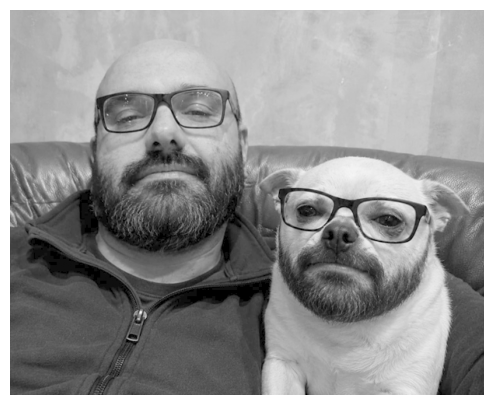

In [13]:
gamma = 0.5
pot = np.clip(((gray / 255.0) ** gamma) * 255, 0, 255).astype(np.uint8)
plt.imshow(pot, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### Transformação logarítmica

O logaritmo comprime as intensidades altas e expande as baixas: $s = c\,\log(1 + r)$. Realça detalhes nas partes escuras sem estourar as claras.

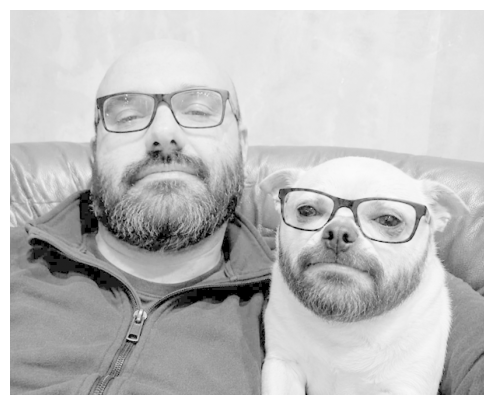

In [14]:
c = 255 / np.log(1 + gray.max())
log = np.clip(c * np.log(1.0 + gray.astype(float)), 0, 255).astype(np.uint8)
plt.imshow(log, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

## Equalização de histograma

As transformações acima usam uma curva fixa. A **equalização** vai além: ela calcula a curva automaticamente a partir da distribuição da imagem, redistribuindo as intensidades para ocupar toda a faixa. É o remédio clássico para baixo contraste.

Aplicamos sobre a versão de baixo contraste que criamos.

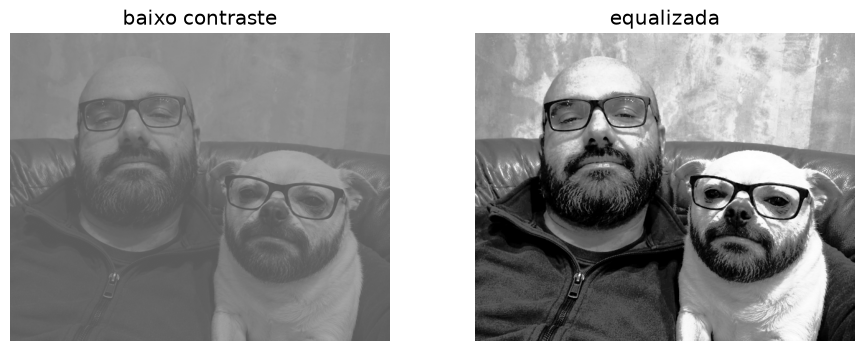

In [15]:
eq = cv2.equalizeHist(baixo)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(baixo, cmap='gray', vmin=0, vmax=255); axes[0].set_title('baixo contraste'); axes[0].axis('off')
axes[1].imshow(eq, cmap='gray', vmin=0, vmax=255); axes[1].set_title('equalizada'); axes[1].axis('off')
plt.show()

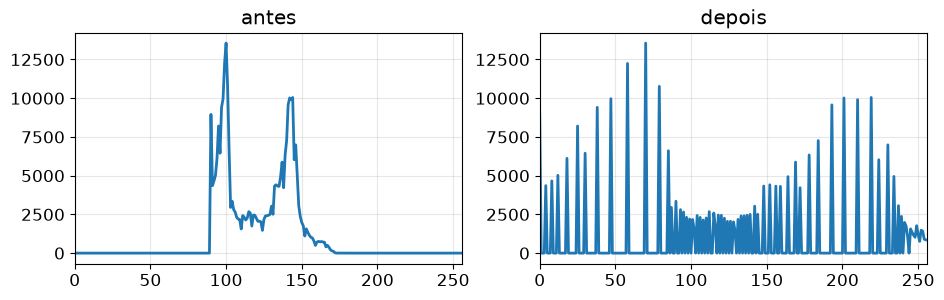

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(cv2.calcHist([baixo], [0], None, [256], [0, 256])); axes[0].set_xlim([0, 256]); axes[0].set_title('antes')
axes[1].plot(cv2.calcHist([eq], [0], None, [256], [0, 256])); axes[1].set_xlim([0, 256]); axes[1].set_title('depois')
plt.show()

O histograma que estava espremido num pico se espalha por toda a faixa, e o contraste reaparece. A equalização usa a função de distribuição acumulada (a soma corrida do histograma) como curva de mapeamento.

### Equalização adaptativa (CLAHE)

A equalização global aplica a mesma curva à imagem inteira e pode estourar regiões amplas, como um céu. O **CLAHE** equaliza em blocos locais e limita o ganho de contraste, ficando mais natural.

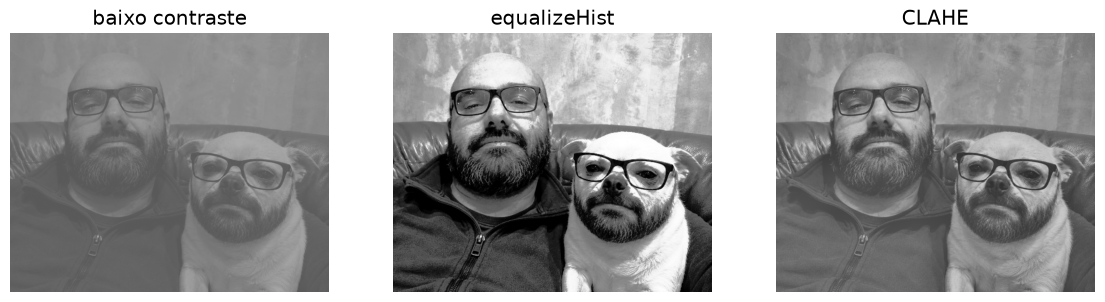

In [17]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
cl = clahe.apply(baixo)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (nome, im) in zip(axes, [('baixo contraste', baixo), ('equalizeHist', eq), ('CLAHE', cl)]):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255); ax.set_title(nome); ax.axis('off')
plt.show()

### Em imagem colorida

Equalizar os três canais RGB separadamente distorce as cores. O caminho correto é converter para HSV e equalizar apenas o canal **V**, a luminância, preservando o matiz e a saturação.

In [18]:
img_low = np.clip(img * 0.4 + 60, 0, 255).astype(np.uint8)
hsv = cv2.cvtColor(img_low, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
v_eq = cv2.equalizeHist(v)
img_eq = cv2.cvtColor(cv2.merge([h, s, v_eq]), cv2.COLOR_HSV2BGR)

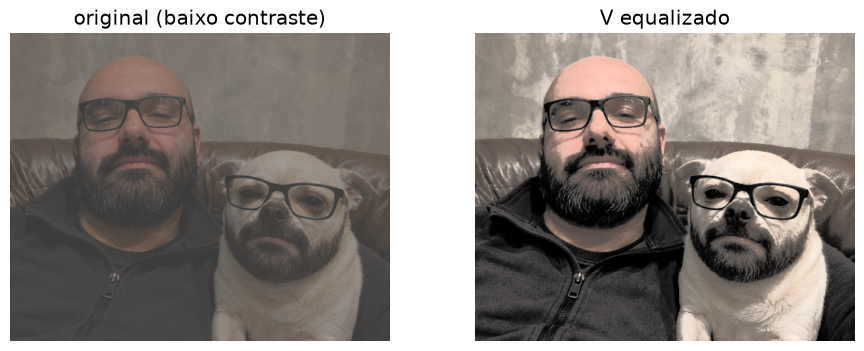

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(img_low[:, :, ::-1]); axes[0].set_title('original (baixo contraste)'); axes[0].axis('off')
axes[1].imshow(img_eq[:, :, ::-1]); axes[1].set_title('V equalizado'); axes[1].axis('off')
plt.show()

As cores continuam coerentes porque só a luminância foi ajustada. Foi por isso que o espaço HSV, visto na aula anterior, separa a cor da iluminação.

## Do histograma à decisão

Ler o histograma não é um fim em si: ele orienta escolhas. A mais direta é o limiar de binarização, que separa a imagem em dois grupos a partir de um valor de corte.

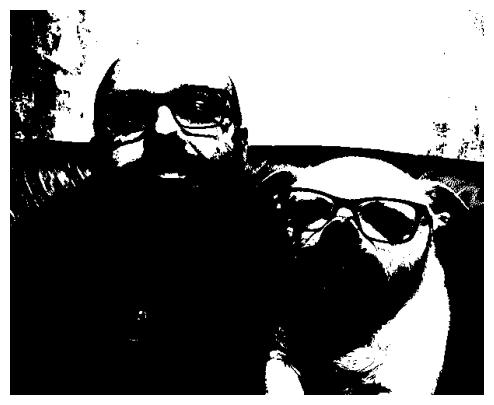

In [20]:
_, binaria = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
plt.imshow(binaria, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

## Síntese

Nesta aula olhamos a imagem por dentro. O histograma resume a distribuição das intensidades e serve de diagnóstico. As transformações de intensidade, da soma de brilho à equalização adaptativa, remapeiam essa distribuição para revelar informação.

Fica uma pergunta para a próxima aula: de onde vêm esses valores de intensidade? A resposta está na formação da imagem, no caminho da luz até o pixel.